# Chicago Light Maps for the Bird-Collision Model
**Date:** 2026-09-30

## What this notebook does
We want to know if bird collisions are linked to artificial light. To test that, we first need **maps of light** that
we can match to collision locations.

This notebook makes four simple maps of Chicago from one satellite night photo, on a grid of 100 m x 100 m squares:

| Map | Question it answers |
|---|---|
| **Brightness** | How much light comes from this square? |
| **Lit share** | How much of this square is lit? |
| **Blueness** (B/G) | Is the light white/bluish? White LED lamps give high values. |
| **Redness** (R/G) | Is the light orange? Old sodium street lamps give high values. |

**Why color matters:** research suggests birds react more to blue-rich (white LED) light than to orange light. So we
look at *what kind* of light, not just *how much*.

## Step 0. Setup
The satellite is **SDGSAT-1**. It took this photo at about **9:30 pm on Sept 15, 2025**.
We use its **color image** (red, green, blue), where each pixel is 40 m wide. One file contains all of Chicago.

In [7]:
import os, sys
# technical fix so map projections work in this Python environment (safe to ignore)
os.environ["PROJ_DATA"] = os.environ["PROJ_LIB"] = os.path.join(sys.prefix, "share", "proj")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import rasterio
from rasterio.windows import from_bounds
from rasterio.transform import from_origin
from rasterio.warp import reproject, transform_bounds, transform, Resampling

SCENE = "KX10_GIU_20250916_W89.00_N41.66_202500097282_L4A"
COLOR_FILE = f"{SCENE}/{SCENE}_B_RGB.tif"      # color image (camera B covers Chicago)
CALIB_FILE = f"{SCENE}/{SCENE}.calib.xml"      # numbers to convert pixel values into light units
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs("figures", exist_ok=True)

CHICAGO = (-87.95, 41.62, -87.50, 42.05)       # west, south, east, north (longitude / latitude)

## Step 1. Read the image and convert it to light units
The file stores each pixel as a raw number from 0 to 4095. To compare red, green and blue fairly, we convert each raw
number into real light units (radiance) with a formula from the calibration file:

> light = raw number x gain + bias

A raw value of **0** means "no data" (outside the photo), so we mark it as empty (`NaN`).

In [8]:
# read the gain and bias for each color from the calibration file
with open(CALIB_FILE, encoding="gb2312") as f:
    calib = ET.fromstring(f.read()).find(".//GIU")

def gain_bias(color):
    gain = float(calib.findtext(f".//RADIANCE_GAIN_BAND_{color}"))
    bias = float(calib.findtext(f".//RADIANCE_BIAS_BAND_{color}"))
    return gain, bias

# read only the Chicago part of the image
with rasterio.open(COLOR_FILE) as src:
    box = transform_bounds("EPSG:4326", src.crs, *CHICAGO)
    window = from_bounds(*box, transform=src.transform).round_offsets().round_lengths()
    raw = src.read(window=window).astype("float32")      # 3 layers: red, green, blue
    image_transform = src.window_transform(window)
    image_crs = src.crs

inside_photo = (raw > 0).all(axis=0)

light = {}
for i, color in enumerate(["RED", "GREEN", "BLUE"]):
    gain, bias = gain_bias(color)
    light[color] = np.where(inside_photo, raw[i] * gain + bias, np.nan)

print("Image size:", raw.shape[1], "x", raw.shape[2], "pixels (40 m each)")

Image size: 1201 x 944 pixels (40 m each)


## Step 2. Keep only pixels with trustworthy color
Color is only meaningful where there is real light. A pixel is **usable** if:

1. **It is lit.** The green value is at least 20. Green is the brightest color in this image, so it is the fairest test.
2. **It is not maxed out.** If a color hits the top value (4095), its true value is unknown and the color would be wrong.
   This only happens at a few very bright places, like stadiums.
3. **It is not a moving light.** The satellite takes red, green and blue at slightly different moments. A plane or boat
   moves in between, so its colors land on different pixels and look impossible (for example, 10 times more blue
   than green). We drop the most extreme 0.1% of colors to remove these.

In [9]:
red, green, blue = light["RED"], light["GREEN"], light["BLUE"]

is_lit = inside_photo & (raw[1] >= 20)
is_maxed_out = (raw >= 4095).any(axis=0)

with np.errstate(divide="ignore", invalid="ignore"):
    blueness_px = blue / green
    redness_px = red / green

is_weird = np.zeros_like(is_lit)
for ratio in [blueness_px, redness_px]:
    low, high = np.percentile(ratio[is_lit & ~is_maxed_out], [0.1, 99.9])
    is_weird |= (ratio < low) | (ratio > high)

usable = is_lit & ~is_maxed_out & ~is_weird

print(f"Pixels inside the photo: {inside_photo.sum():,}")
print(f"  lit:                   {is_lit.sum():,}")
print(f"  removed, maxed out:    {(is_lit & is_maxed_out).sum():,}")
print(f"  removed, moving light: {(is_lit & ~is_maxed_out & is_weird).sum():,}")
print(f"  usable for color:      {usable.sum():,}")

Pixels inside the photo: 1,133,744
  lit:                   771,964
  removed, maxed out:    680
  removed, moving light: 2,988
  usable for color:      768,296


## Step 3. Put everything on a 100 m grid
The collision model uses squares of **100 m x 100 m**, in the map system EPSG:26916. We use the same.

Each 100 m square covers parts of several 40 m pixels. For each square we take the **average** of the pixels inside it
(weighted by how much of each pixel falls in the square).

Then, for each square:
- **Brightness** = average total light (red + green + blue). We use a log scale because the city is thousands of times
  brighter than parks.
- **Lit share** = the fraction of the square with usable color (0 to 1).
- **Blueness** = total blue / total green, using only usable pixels.
- **Redness** = total red / total green, using only usable pixels.

We divide *totals* instead of averaging each pixel's ratio, so bright lamps count more than faint, noisy pixels.
If less than 25% of a square is lit, its color is based on too little light, so we leave it empty.

In [10]:
GRID_CRS = "EPSG:26916"
CELL = 100   # meters

# grid covering Chicago, with edges on round 100 m numbers
west, south, east, north = transform_bounds("EPSG:4326", GRID_CRS, *CHICAGO)
west, south = np.floor(west / CELL) * CELL, np.floor(south / CELL) * CELL
east, north = np.ceil(east / CELL) * CELL, np.ceil(north / CELL) * CELL
grid_transform = from_origin(west, north, CELL, CELL)
grid_width, grid_height = int((east - west) / CELL), int((north - south) / CELL)

def to_100m(layer):
    # average a 40 m layer into the 100 m grid
    out = np.full((grid_height, grid_width), np.nan, dtype="float32")
    reproject(layer.astype("float32"), out,
              src_transform=image_transform, src_crs=image_crs, src_nodata=np.nan,
              dst_transform=grid_transform, dst_crs=GRID_CRS, dst_nodata=np.nan,
              resampling=Resampling.average)
    return out

def only_usable(layer):
    # usable pixels keep their light; other pixels in the photo count as 0 light
    return np.where(usable, layer, np.where(inside_photo, 0, np.nan))

total_light = to_100m(red + green + blue)
lit_share = to_100m(np.where(inside_photo, usable, np.nan))
red_100, green_100, blue_100 = to_100m(only_usable(red)), to_100m(only_usable(green)), to_100m(only_usable(blue))

with np.errstate(divide="ignore", invalid="ignore"):
    enough_light = lit_share >= 0.25
    maps = {
        "brightness": np.log10(total_light),
        "lit_share": lit_share,
        "blueness": np.where(enough_light, blue_100 / green_100, np.nan),
        "redness": np.where(enough_light, red_100 / green_100, np.nan),
    }

print(f"Grid: {grid_width} x {grid_height} = {grid_width * grid_height:,} squares of 100 m")
print(f"Squares with enough light for color: {enough_light.sum():,}")
pd.DataFrame({name: pd.Series(m.ravel()).describe() for name, m in maps.items()}).T.round(3)

Grid: 379 x 481 = 182,299 squares of 100 m
Squares with enough light for color: 130,846


,count,mean,std,min,25%,50%,75%,max
brightness,182299.0,-3.010,0.876,-4.291,-4.039,-2.751,-2.307,-1.067
lit_share,182299.0,0.676,0.435,0.000,0.031,1.000,1.000,1.000
blueness,130846.0,0.400,0.184,0.023,0.278,0.391,0.497,2.523
redness,130846.0,2.229,0.812,0.079,1.819,2.236,2.606,10.760


## Step 4. Look at the maps

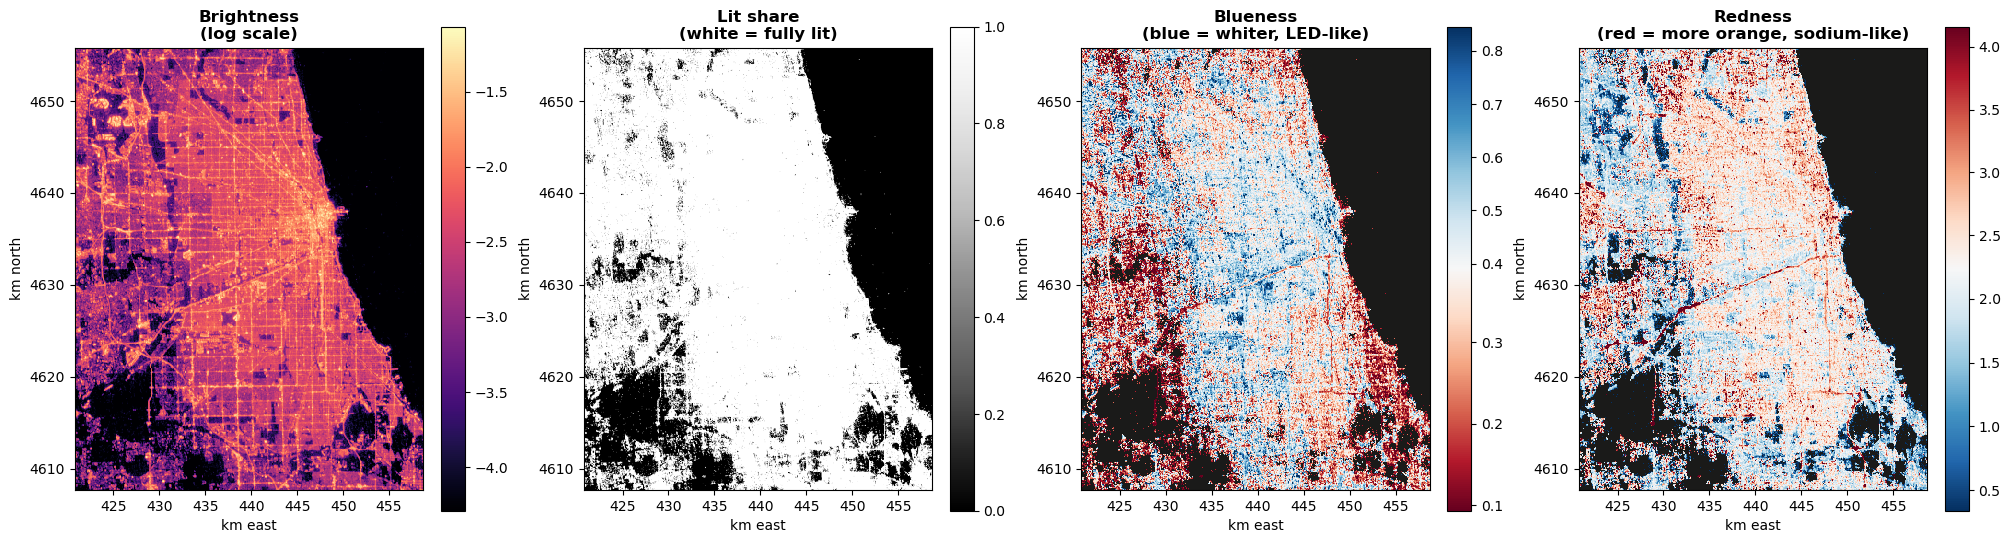

In [11]:
extent_km = [west / 1000, east / 1000, south / 1000, north / 1000]

def centered_on_median(m):
    # color scale: white = typical Chicago value, stronger color = further from typical
    v = m[np.isfinite(m)]
    low, mid, high = np.percentile(v, [2, 50, 98])
    return plt.matplotlib.colors.TwoSlopeNorm(vmin=low, vcenter=mid, vmax=high)

panels = [
    ("brightness", "Brightness\n(log scale)", "magma", None),
    ("lit_share", "Lit share\n(white = fully lit)", "Greys_r", None),
    ("blueness", "Blueness\n(blue = whiter, LED-like)", "RdBu",
     centered_on_median(maps["blueness"])),
    ("redness", "Redness\n(red = more orange, sodium-like)", "RdBu_r",
     centered_on_median(maps["redness"])),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 7), layout="constrained")

for ax, (name, title, cmap, norm) in zip(axes, panels):
    im = ax.imshow(
        maps[name],
        extent=extent_km,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )
    ax.set_facecolor("#1a1a19")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("km east")
    ax.set_ylabel("km north")
    plt.colorbar(im, ax=ax, shrink=0.7)

fig.savefig("figures/10_light_maps.png", dpi=150, bbox_inches="tight")
plt.show()

**How to read the maps** (black = no data or not enough light, mostly Lake Michigan):

- **Brightness:** downtown (the Loop, by the lake in the middle) is the brightest. Main streets show up as a grid of
  bright lines. Dark patches are large parks, forest preserves and the lake.
- **Lit share:** almost all land is lit. Only the lake and large green spaces stay black.
- **Blueness:** the city is a mix. The west and south edges (outside the city limits) look less blue. A possible
  reason: Chicago switched its own streetlights to white LED, and nearby towns may not have. We have not checked this.
- **Redness:** highways show up as thin red (orange-light) lines, for example the diagonal I-55 southwest of downtown.
  A possible reason: highway lights are run by the state, not by the city's LED program.

## Step 5. Two quick checks

### Check A: does our "lit" rule change the answer?
Our first notebook called a pixel lit only if **all three colors** were at least 20. But blue is always the dimmest color,
and orange lamps have very little blue. So that rule throws out orange-lit pixels first, and the city looks more
white/blue than it really is. Here we compare the two rules:

In [12]:
on_photo = inside_photo & ~is_maxed_out
rows = []
for threshold in [10, 20, 50, 100]:
    for rule, pixels in [("green only (new)", on_photo & (raw[1] >= threshold)),
                         ("all three colors (old)", on_photo & (raw >= threshold).all(axis=0))]:
        rows.append({"threshold": threshold, "rule": rule,
                     "city blueness": blue[pixels].sum() / green[pixels].sum()})
check_a = pd.DataFrame(rows).pivot(index="threshold", columns="rule", values="city blueness").round(3)
check_a

rule,all three colors (old),green only (new)
threshold,,
10,0.469,0.456
20,0.476,0.456
50,0.494,0.456
100,0.521,0.458


**Result:** with the old rule, the city's blueness goes from 0.469 to 0.521 just by changing the cutoff, so the answer
depends on the rule. With the new rule it stays at 0.456 to 0.458. **The new rule gives a stable answer, so we use it.**

### Check B: is color different from brightness?
If color were just another way of measuring brightness, it would add nothing new to the collision model.
A correlation (r) near 0 means the two are unrelated, and near 1 means they are basically the same.

In [13]:
both = np.isfinite(maps["blueness"]) & np.isfinite(maps["brightness"])
r_bright_blue = np.corrcoef(maps["brightness"][both], maps["blueness"][both])[0, 1]
r_bright_red = np.corrcoef(maps["brightness"][both], maps["redness"][both])[0, 1]
r_blue_red = np.corrcoef(maps["blueness"][both], maps["redness"][both])[0, 1]
print(f"brightness vs blueness: r = {r_bright_blue:.2f}")
print(f"brightness vs redness:  r = {r_bright_red:.2f}")
print(f"blueness vs redness:    r = {r_blue_red:.2f}")

brightness vs blueness: r = 0.31
brightness vs redness:  r = 0.37
blueness vs redness:    r = 0.01


**Result:**
- Brightness vs. color: r is about 0.3 to 0.4, a weak link. **Color adds new information** beyond brightness.
- Blueness vs. redness: r = 0.01, no link. They are not opposites. Each measures something different, so we keep both.

## Step 6. Save the maps
Each map is saved as a GeoTIFF (an image that knows where it is on Earth), ready to join with collision locations.

In [14]:
profile = {"driver": "GTiff", "dtype": "float32", "count": 1, "nodata": np.nan,
           "crs": GRID_CRS, "transform": grid_transform, "width": grid_width, "height": grid_height,
           "compress": "deflate"}
for name, m in maps.items():
    path = f"{OUT_DIR}/light_{name}_100m.tif"
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(m.astype("float32"), 1)
    print("saved", path)

saved outputs/light_brightness_100m.tif
saved outputs/light_lit_share_100m.tif
saved outputs/light_blueness_100m.tif
saved outputs/light_redness_100m.tif


## Step 7. Look up the light at any location
This is how collision records will get their light values: give longitudes and latitudes, and get back the value of
each map at those points. Here we try a few well-known places.

In [15]:
def light_at(lon, lat):
    x, y = transform("EPSG:4326", GRID_CRS, list(lon), list(lat))
    rows, cols = rasterio.transform.rowcol(grid_transform, x, y)
    return pd.DataFrame({name: [m[r, c] for r, c in zip(rows, cols)] for name, m in maps.items()})

places = pd.DataFrame({
    "place": ["The Loop (downtown)", "McCormick Place", "Montrose Point bird sanctuary", "Lake Michigan, 3 km out"],
    "lon": [-87.6278, -87.6167, -87.6340, -87.5700],
    "lat": [41.8819, 41.8517, 41.9636, 41.9000],
})
pd.concat([places, light_at(places.lon, places.lat)], axis=1).round(3)

,place,lon,lat,brightness,lit_share,blueness,redness
0,The Loop (downtown),-87.628,41.882,-1.538,1.000,0.433,1.510
1,McCormick Place,-87.617,41.852,-2.514,0.976,0.836,1.825
2,Montrose Point bird sanctuary,-87.634,41.964,-3.150,0.561,0.050,1.293
3,"Lake Michigan, 3 km out",-87.570,41.900,-4.291,0.000,NaN,NaN


**Result:**
- The Loop is the brightest place.
- McCormick Place has very white light (blueness about 0.84, roughly twice the city's typical 0.39).
- Montrose Point (a bird sanctuary on the lake) is fairly dim, and its light has very little blue.
- The lake has no light, so its color is empty, as expected.

## What this means for the project
**Research question:** are bird collisions related to artificial light?

- We now have four light maps of Chicago at 100 m, on the same grid system as the collision model.
- **Color gives new information.** It is only weakly related to brightness (Check B), so it can tell us something
  brightness alone cannot, for example whether collisions are more common near white LED light than near orange light.
- The maps also describe **current lighting in the Lakefront Protection Ordinance area**, which the final memo asks for,
  once we have the Public and Private Zone boundaries.

**Limits to keep in mind**
- This is **one night** (Sept 15, 2025, about 9:30 pm). Collisions were recorded from 2010 to 2024, and Chicago switched
  its streetlights from orange sodium to white LED between about 2017 and 2021.
- Blueness and redness are **hints** about lamp type, not proof. City streetlight records could confirm them.
- Collision records show **where dead birds were found**, not where risk is highest, because some places were searched
  much more than others.

**Next steps**
1. Get the collision file and Winnie's grid, then join light values to every collision (Step 7).
2. Get the ordinance zone boundaries and compare light in the Public vs. Private Zone.
3. Later, if useful: add the 500 m and 1000 m neighborhood versions that Winnie's model uses.